# Download libraries and read data

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [23]:
# Loading the dataset and previewing the first rows
df = pd.read_csv('C:/Users/sanad/Downloads/US-pumpkins.csv')
df.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


# Data Preprocessing

In [24]:
# Understanding data types and statistical summary
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   City Name        1757 non-null   object 
 1   Type             45 non-null     object 
 2   Package          1757 non-null   object 
 3   Variety          1752 non-null   object 
 4   Sub Variety      296 non-null    object 
 5   Grade            0 non-null      float64
 6   Date             1757 non-null   object 
 7   Low Price        1757 non-null   float64
 8   High Price       1757 non-null   float64
 9   Mostly Low       1654 non-null   float64
 10  Mostly High      1654 non-null   float64
 11  Origin           1754 non-null   object 
 12  Origin District  131 non-null    object 
 13  Item Size        1478 non-null   object 
 14  Color            1141 non-null   object 
 15  Environment      0 non-null      float64
 16  Unit of Sale     162 non-null    object 
 17  Quality       

,Grade,Low Price,High Price,Mostly Low,Mostly High,Environment,Quality,Condition,Appearance,Storage,Crop,Trans Mode,Unnamed: 24
count,0.0,1757.000000,1757.000000,1654.000000,1654.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,124.571338,132.970939,128.170550,132.491802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,83.876591,89.524958,86.512161,88.442967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,0.240000,0.240000,0.240000,0.240000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,24.000000,24.500000,24.625000,26.125000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,140.000000,150.000000,147.000000,150.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,180.000000,200.000000,185.000000,200.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,480.000000,480.000000,480.000000,480.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
df.isnull().sum()

City Name             0
Type               1712
Package               0
Variety               5
Sub Variety        1461
Grade              1757
Date                  0
Low Price             0
High Price            0
Mostly Low          103
Mostly High         103
Origin                3
Origin District    1626
Item Size           279
Color               616
Environment        1757
Unit of Sale       1595
Quality            1757
Condition          1757
Appearance         1757
Storage            1757
Crop               1757
Repack                0
Trans Mode         1757
Unnamed: 24        1757
Unnamed: 25        1654
dtype: int64

In [27]:
# Selection Features
df = df[['Date', 'City Name', 'Package', 'Variety', 'Origin', 'Item Size', 'Low Price', 'High Price']]

In [28]:
# Text processing: A constant value was used ('Unknown') .

text_columns = ['City Name', 'Package', 'Variety', 'Origin', 'Item Size']
for col in text_columns:
    df[col] = df[col].fillna('Unknown')

# Number processing: The average assignment method was used to fill in the missing price gaps.

df['High Price'] = df['High Price'].fillna(df['High Price'].mean())
df['Low Price'] = df['Low Price'].fillna(df['Low Price'].mean())

In [29]:
df.isnull().sum()

Date          0
City Name     0
Package       0
Variety       0
Origin        0
Item Size     0
Low Price     0
High Price    0
dtype: int64

In [31]:
levels = ['sml', 'med', 'med-lge', 'lge', 'xlge', 'jbo', 'exjbo']
size_mapping = {size: i+1 for i, size in enumerate(levels)}

df['Item_Size_Num'] = df['Item Size'].map(size_mapping)

print(df[['Item Size', 'Item_Size_Num']].head(5))

  Item Size  Item_Size_Num
0       lge            4.0
1       lge            4.0
2       med            2.0
3       med            2.0
4       lge            4.0


In [32]:
median_size = df['Item_Size_Num'].median() 
df['Item_Size_Num'] = df['Item_Size_Num'].fillna(median_size)

In [33]:
# Remove Outliers (IQR Method) on High Price
Q1 = df['High Price'].quantile(0.25)
Q3 = df['High Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['High Price'] >= lower_bound) & (df['High Price'] <= upper_bound)]

In [34]:
# Date conversion

df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')
df['Month'] = df['Date'].dt.month
df['Weekday'] = df['Date'].dt.weekday

In [35]:
# Filtering Variety Types
selected_varieties = ['HOWDEN TYPE', 'PIE TYPE', 'MINIATURE', 'FAIRYTALE']
df = df[df['Variety'].isin(selected_varieties)]

In [37]:
# Increase FAIRYTALE by 25%

fairytale_rows = df[df['Variety'] == 'FAIRYTALE']
n_add = int(len(fairytale_rows) * 0.25)
fairytale_extra = fairytale_rows.sample(n=n_add, replace=True, random_state=42)
df = pd.concat([df, fairytale_extra], ignore_index=True)

In [39]:
df['Variety'].value_counts()

Variety
HOWDEN TYPE    542
PIE TYPE       467
MINIATURE      310
FAIRYTALE      206
Name: count, dtype: int64

# Binarization


In [40]:
# Create Target Variable
threshold = df['High Price'].mean()

df['Price_Category'] = df['High Price'].apply(lambda x: 1 if x > threshold else 0)

# EDA Visualization

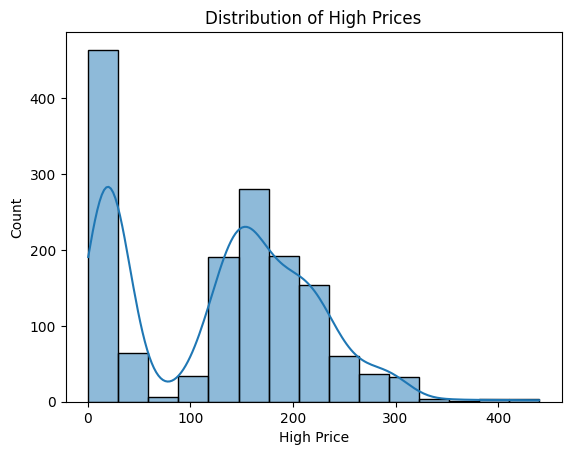

In [41]:
sns.histplot(df['High Price'], kde=True)
plt.title("Distribution of High Prices")
plt.show()

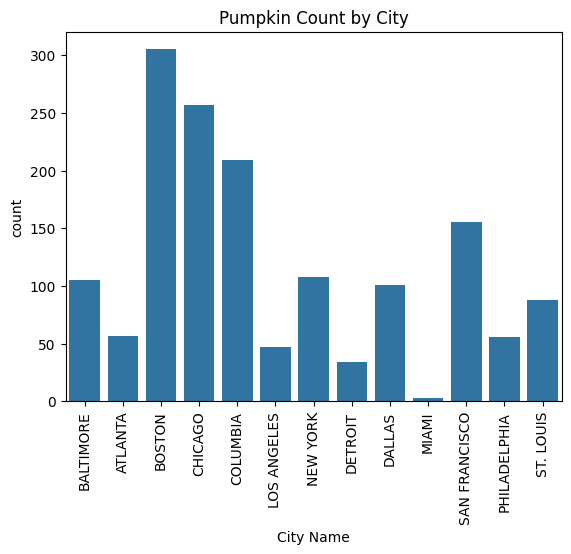

In [42]:
sns.countplot(x='City Name', data=df)
plt.xticks(rotation=90)
plt.title("Pumpkin Count by City")
plt.show()

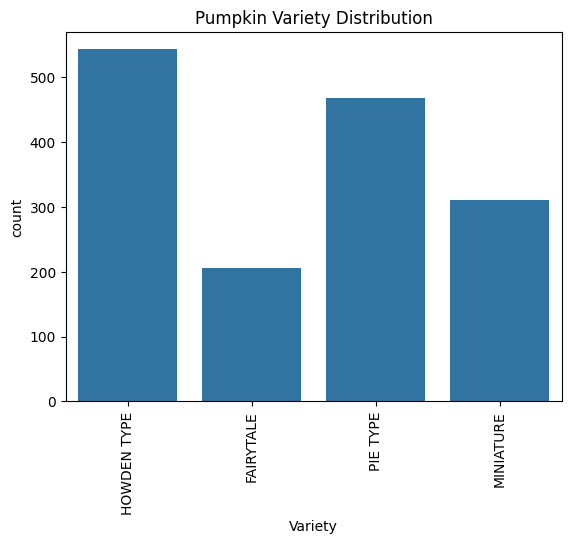

In [43]:
sns.countplot(x='Variety', data=df)
plt.xticks(rotation=90)
plt.title("Pumpkin Variety Distribution")
plt.show()

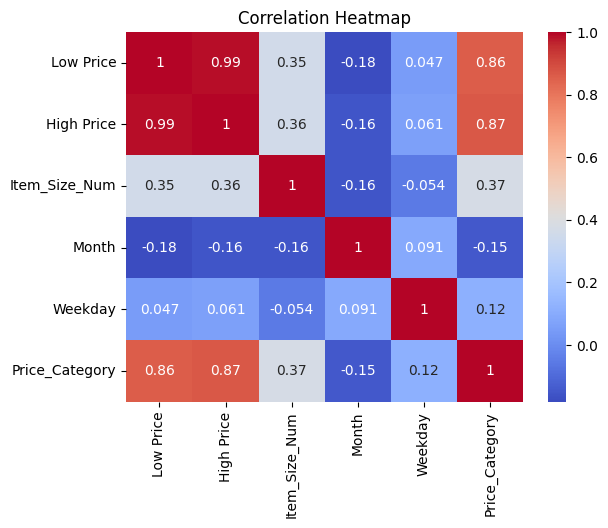

In [44]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# One-Hot Encoding

In [46]:
X = df[['City Name', 'Package', 'Variety', 'Origin', 'Item_Size_Num', 'Month', 'Weekday', 'Low Price']]
X = pd.get_dummies(X, columns=['City Name', 'Package', 'Variety', 'Origin'], drop_first=True)
y = df['Price_Category']

# Split data

In [47]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split
# Train 70%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# Validation 15% + Test 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Logistic Regression Training

In [48]:
# Logistic Regression Model

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Evaluation


In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Accuracy: 0.9737991266375546
Precision: 0.9637681159420289
Recall: 0.9925373134328358
F1 Score: 0.9779411764705882
